---
title: Week 4.2 Tutorial 2, Sulfurous Acid System
subtitle: Orchestra Scenario, Carbonate buffer system
author:
  - name: Timo Heimovaara
    affiliations: Delft University of Technology, department of Geoscience & Engineering
    orcid: 
    email: t.j.heimovaara@tudelft.nl
license: CC-BY-NC-ND-4.0 (https://creativecommons.org/licenses/by-nc-nd/4.0/).
date: 2026-01-07
kernelspec:
    name: python3
    display_name: 'Python 3.13'
---

## Studying the sulfurous acid system


In [1]:
# Import libraries required for running all simulations
import os
import sys
from IPython.utils import capture
from IPython.display import display, Markdown
from pathlib import Path
from contextlib import chdir

import numpy as np
import matplotlib.pyplot as plt
import PyORCHESTRA # here, the ORCHESTRA submodule is imported
import pandas as pd
import seaborn as sns

%matplotlib widget
sns.set()

# Prepare a file to capture PyOrchestra output
capture_file = open("pyorchestra_output.log", "w")


# pyOrchestra is implemented in C++
# Save original stdout file descriptor
original_stdout_fd = sys.stdout.fileno()

# Duplicate original stdout so we can restore it later
saved_stdout_fd = os.dup(original_stdout_fd)



# We need to import some Orchestra files. We need to know the path layout on 
# the local machine:
def find_book_root(start: Path | None = None) -> Path:
    """
    Walk upward from `start` (or CWD) until a directory containing Jupyter Book
    marker files is found. Returns the path to the book root.
    Raises FileNotFoundError if no root is found.
    """
    config_any = {"_config.yml", "_config.yaml"}      # some projectrs use .yaml
    myst_any = {"myst.yml", "myst.yaml"}            # jupyter-book uses _toc.yml

    cur = Path(Path.cwd()).resolve()

    for parent in [cur, *cur.parents]:
        children = {f.name for f in parent.iterdir()} if parent.exists() else set()
        has_any_config = bool(config_any & children)
        has_any_myst = bool(myst_any & children)
        if has_any_config and has_any_myst:
            return parent

    raise FileNotFoundError(
        f"Could not find Jupyter Book root (no _config.y* and myst.y* found above {cur})"
    )


def path_from_book_root(*parts: str | Path) -> Path:
    root = find_book_root()
    p = (root.joinpath(*parts)).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")
    return p

# In order for orchestra to run we need to change directory to the directory with the input file:


# Example usage:
# input_file = path_from_book_root("content", "week 02", "Orchestra_simulation", "chemistry1.inp")
# print("Input file:", input_file)
   
orchestra_path = path_from_book_root("content", "week 4.2", "Week 4.2_Tutorial-2-ChemicalBuffersSystems_sulfurous_acid")
# print(orchestra_path)

## Define chemical system: Sulfurous Acid, and Water using the ORCHESTRA-GUI

Using all insights from above we generated the following master species table: 

|Primary entity|Phase|Input Variable|Fix log activity|Log activity|Concentration|Phase|Expression|
|--|--|--|--|--|--|--|--|
|Ar[g]|gas||x|0||||
|Cl-|diss||||1.0e-9|tot||
|H+|diss|pH|x|7.0|||H.logact=-pH|
|H2O|liter||x|-0.0||||
|Na+|diss||||0.2|tot||
|SO3-2|diss||||0.1|tot||

Orchestra will use these primary entities, and their initial values to calculate the total elemental composition in the complete system. The fixed log-activties indicate that the total can vary during the simulation, as long as the log-activity condition is maintained or because Orchestra uses these values to balance the charge of the solution (Na+.tot and Cl-.tot). 




## Running the Sulfurous Acid-Water scenario in a Python notebook

We follow the same systematic approach as Tutorial 1, which consists of the following standard steps:
1. define the domain for our problem
2. define the primary species which change during our scenario
3. initialize the problem
4. run the problem
5. process the output

### 1. Define the domain
For our analysis we choose to work with a system containing 1 liter of water and 1 liter of gas phase. The volume of the solid phase is small with respect the total volume and will be neglected for now.

### 2. Define the primary species
The primary species are as defined above with the ORCHESTRA GUI. Please note that the values required by ORCHESTRA have to be in moles. In order to get moles/liter the volume of water has to be set to 1 liter, and the density of water need to be given as well.

### 3. Initialise the problem 
The initial condition for our problem will be defined by setting the amounts of $\text{SO}_3^{-2}$ and $\text{Na}^+$ in our system. 



In [2]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry1.inp' file.
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_sulfurous_acid_buffer.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    InVars = np.array(['pH',
                       'Na+.tot', 
                       'SO3-2.tot',
                       'Cl-.tot',
                       'watervolume',
                       'gasvolume_fixed',
                       'gastype',
                       ])
    
    # We select the output from Orchestra we need to use
    OutVars = np.array(['pH', 'H+.con', 'H+.tot', 'H+.logact',
                        'OH-.tot', 'OH-.con', 'OH-.logact',
                        'SO3-2.tot', 'SO3-2.con', 'SO3-2.diss', 'SO3-2.logact',
                        'H[SO3]-.tot', 'H[SO3]-.con', 'H[SO3]-.diss', 'H[SO3]-.logact',
                        'H2[SO3].tot', 'H2[SO3].con', 'H2[SO3].diss', 'H2[SO3].logact',
                        'SO2.tot', 'SO2.con', 'SO2.diss', 'SO2.logact',
                        'Cl-.tot', 'Cl-.con', 'Cl-.logact', 'Cl-.diss', 
                        'Na+.tot', 'Na+.con', 'Na+.logact', 'Na+.diss',
                        'I', 'chargebalance', 'watervolume', 'gasvolume','pressure' ])

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    p = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above
    p.initialise(InputFile, NoCells, InVars, OutVars)


Reading and expanding calculator new stylechemistry_sulfurous_acid_buffer.inp
Scanning file: chemistry_sulfurous_acid_buffer.inp
Scanning file: objects2026_THe.txt
Scanning file: chemistry_sulfurous_acid_buffer.inp
Scanning file: objects2026_THe.txt
Including file: chemistry_sulfurous_acid_buffer.inp
Scanning file: objects2026_THe.txt
0.019 sec.
	Reading variables .... 0.007 s
testing:
11:pH
13:Na+.tot
15:SO3-2.tot
10:Cl-.tot
16:watervolume
17:gasvolume_fixed
18:gastype
11:pH
19:H+.con
20:H+.tot
21:H+.logact
22:OH-.tot
23:OH-.con
24:OH-.logact
15:SO3-2.tot
25:SO3-2.con
26:SO3-2.diss
14:SO3-2.logact
27:H[SO3]-.tot
28:H[SO3]-.con
29:H[SO3]-.diss
30:H[SO3]-.logact
31:H2[SO3].tot
32:H2[SO3].con
33:H2[SO3].diss
34:H2[SO3].logact
35:SO2.tot
36:SO2.con
37:SO2.diss
38:SO2.logact
10:Cl-.tot
39:Cl-.con
9:Cl-.logact
40:Cl-.diss
13:Na+.tot
41:Na+.con
12:Na+.logact
42:Na+.diss
3:I
7:chargebalance
16:watervolume
43:gasvolume
44:pressure
Initialise Completed! the following IO parameters will be used:

In [3]:
orchestra_path

PosixPath('/home/theimovaara/BackupTHe/GitHub/oit_chemistry_for_earth_sciences/chemistry_book/content/week 4.2/Week 4.2_Tutorial-2-ChemicalBuffersSystems_sulfurous_acid')

Please note that the output of this code is what ORCHESTRA echos back. ORCHESTRA uses a set of variables in order to store the input variables and the results of the calculations, in this case 33. The top part of the output shows the output requested by us through *OutVars* together with the values used during initialization.

### Run the Problem
The aim of the scenario for now is to see experiment with sulfurous acid buffer system. To see the effect of the buffer we compare acid titration results of a non-buffered system with a buffered system. This is done in a similar fashion as the carbonate buffer system tested in Tutorial 1.

### Step 1: Define the default InVars

In [4]:
# %%
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
SO32_ini = 0.5 #0.3 # moles
Na_ini = 1.0 # moles This implies that we have added 0.1 mol/l Na2SO3 

IN[0][np.where(InVars == 'SO3-2.tot')] = SO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # No Gypsum (initial conditions)
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume_fixed')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

                           0
pH              1.027595e+01
H+.con          5.961356e-11
H+.tot          2.747470e-04
H+.logact      -1.027595e+01
OH-.tot         2.747470e-04
OH-.con         2.747470e-04
OH-.logact     -3.820452e+00
SO3-2.tot       5.000000e-01
SO3-2.con       4.997253e-01
SO3-2.diss      5.000000e-01
SO3-2.logact   -5.064420e-01
H[SO3]-.tot     2.747408e-04
H[SO3]-.con     2.747408e-04
H[SO3]-.diss    2.747408e-04
H[SO3]-.logact -3.612370e+00
H2[SO3].tot     9.368532e-13
H2[SO3].con     9.368532e-13
H2[SO3].diss    9.368532e-13
H2[SO3].logact -1.202833e+01
SO2.tot         9.368532e-13
SO2.con         9.368532e-13
SO2.diss        9.368532e-13
SO2.logact     -1.202833e+01
Cl-.tot         1.000000e-20
Cl-.con         1.746492e-19
Cl-.logact     -1.880913e+01
Cl-.diss        1.746492e-19
Na+.tot         1.000000e+00
Na+.con         1.000000e+00
Na+.logact     -5.129332e-02
Na+.diss        1.000000e+00
I               1.499725e+00
chargebalance   0.000000e+00
watervolume   

### Step 2: Simulate the addition of a strong acid (HCl)
We add acid by adding Cl- in small increments. H+ is added implicitly as we allow Orchestra to balance charge using the pH.

In [5]:
# Define the incremental pH change

Cl_range = np.logspace(-5, 0, 101)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_non_buffered = pd.DataFrame(all_Res,columns=OutVars)

Try a first calculation with iia switched off....
Parsing expressions of chemistry_sulfurous_acid_buffer.inp..... 
Optimizing expressions of chemistry_sulfurous_acid_buffer.inp..... 0.043 sec.
1244 variables, 3199 expressions, 4 equations.
First calculation was successful!
Repeat calculation with iia switched on..
Switching on: logI: -2
Switching on: pH: 1
This was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_aci

## Process Output


In [6]:
Res_non_buffered[['pH','Cl-.tot']]


,pH,Cl-.tot
0,10.268043,0.000010
1,10.267077,0.000011
2,10.265995,0.000013
3,10.264781,0.000014
4,10.263419,0.000016
...,...,...
96,2.659901,0.630957
97,2.367639,0.707946
98,2.085721,0.794328
99,1.758162,0.891251


Text(0, 0.5, 'pH')

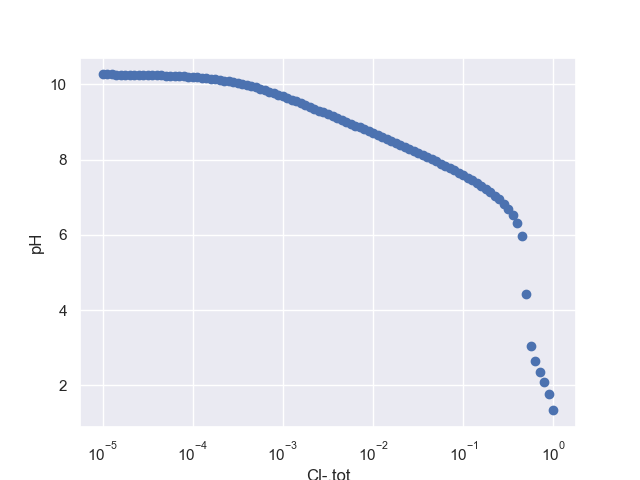

In [7]:
# Process output
# we can easily make the plot 
fig1,ax1 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax1.plot(Res_non_buffered['Cl-.tot'],Res_non_buffered['pH'],'o')
ax1.grid(True)
ax1.set_xscale('log')
ax1.set_xlabel('Cl-.tot')
ax1.set_ylabel(r'pH')


### Assignment: Run the scenario for the sulfurous acid buffered system
 Compare the results with the non-buffered results

In [8]:
# %%
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
SO32_ini = 0.5 #0.3 # moles
Na_ini = 0.75 # moles This implies that we have added 0.1 mol/l Na2SO3 

IN[0][np.where(InVars == 'SO3-2.tot')] = SO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # No Gypsum (initial conditions)
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume_fixed')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

                           0
pH              6.875670e+00
H+.con          1.682907e-07
H+.tot          2.500001e-01
H+.logact      -6.875670e+00
OH-.tot         1.039183e-07
OH-.con         1.039183e-07
OH-.logact     -7.220730e+00
SO3-2.tot       5.000000e-01
SO3-2.con       2.500054e-01
SO3-2.diss      4.999984e-01
SO3-2.logact   -1.008971e+00
H[SO3]-.tot     2.438423e-01
H[SO3]-.con     2.438423e-01
H[SO3]-.diss    2.438423e-01
H[SO3]-.logact -7.146211e-01
H2[SO3].tot     1.860796e-06
H2[SO3].con     1.860796e-06
H2[SO3].diss    1.860796e-06
H2[SO3].logact -5.730301e+00
SO2.tot         1.860796e-06
SO2.con         1.860796e-06
SO2.diss        1.860796e-06
SO2.logact     -5.730301e+00
Cl-.tot         1.000000e-20
Cl-.con         4.785116e-14
Cl-.logact     -1.342184e+01
Cl-.diss        4.785116e-14
Na+.tot         7.500000e-01
Na+.con         7.500000e-01
Na+.logact     -2.266688e-01
Na+.diss        7.500000e-01
I               1.003079e+00
chargebalance   0.000000e+00
watervolume   

In [9]:
# Define the incremental pH change

Cl_range = np.logspace(-5, 0, 101)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_buffered = pd.DataFrame(all_Res,columns=OutVars)

cessful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&

Text(0, 0.5, 'pH')

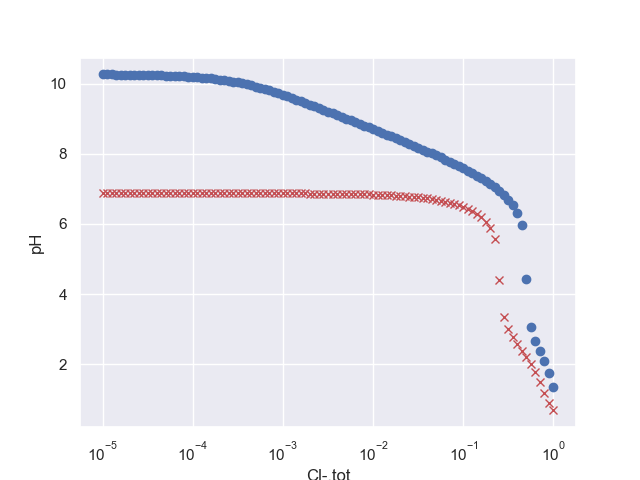

In [10]:
# Process output
# we can easily make the plot 
fig3,ax3 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax3.plot(Res_non_buffered['Cl-.tot'],Res_non_buffered['pH'],'o')
ax3.plot(Res_buffered['Cl-.tot'],Res_buffered['pH'],'rx')
ax3.grid(True)
ax3.set_xscale('log')
ax3.set_xlabel('Cl-.tot')
ax3.set_ylabel(r'pH')
